# INF6422E – Advanced Concepts in Computer Security  
## Practical Work 4 – Winter 2026  

### Semantic and Context-Aware Security Analysis

  
  
## Students  
- Antoine Khoueiry – *Matricule:* 2487137  
- Louis Junior Mpandzo-Otiankouya – *Matricule:* 2421549  

 

## Objective

This lab studies semantic and context-aware intrusion detection using a modern dataset (UNSW-NB15) and a gradient boosting model (XGBoost). Unlike Practical Work 1 (supervised IDS classification), Practical Work 2 (security of ML under adversarial manipulation), and Practical Work 3 (privacy-aware collaborative anomaly detection), Practical Work 4 focuses on interpretation-oriented challenges:

• How to perform both binary and multi-class attack detection using advanced ensemble methods

• How contextual network features (protocol, service, load, timing) influence intrusion behavior

• How misclassifications can be analyzed from a cybersecurity perspective, not only a metrics perspective

• How to connect ML outputs to trustworthy decision-making in SOC environments.
 

## Dataset

This study uses the **UNSW-NB15** dataset, containing modern network traffic with rich contextual features including protocol, service, state, temporal features, traffic behavior, and attack categories.
 

## Notebook Structure

1. Comparative Security Modeling (Binary & Multi-Class XGBoost)
2. Context-Aware Feature Semantics & Attack Behavior Profiling
3. Misclassification & Security Error Analysis
4. Trustworthy Security Interpretation (SOC Perspective)

# 1. Comparative Security Modeling

### 1.1 Binary Intrusion Detection



In [2]:
import pandas as pd
import numpy as np

#  Load feature names 
features_df = pd.read_csv("Datasets/NUSW-NB15_features.csv", encoding='latin-1')
column_names = features_df['Name'].tolist()

#  Load training and testing sets 
train_df = pd.read_csv("Datasets/UNSW_NB15_training-set.csv")
test_df = pd.read_csv("Datasets/UNSW_NB15_testing-set.csv")

print(f"Training set: {train_df.shape[0]} samples, {train_df.shape[1]} columns")
print(f"Testing set:  {test_df.shape[0]} samples, {test_df.shape[1]} columns")

print("\nColumns:", train_df.columns.tolist())
print("\nAttack categories:", train_df['attack_cat'].unique())
print("\nLabel distribution (train):")
print(train_df['label'].value_counts())

Training set: 175341 samples, 45 columns
Testing set:  82332 samples, 45 columns

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Attack categories: ['Normal' 'Backdoor' 'Analysis' 'Fuzzers' 'Shellcode' 'Reconnaissance'
 'Exploits' 'DoS' 'Worms' 'Generic']

Label distribution (train):
label
1    119341
0     56000
Name: count, dtype: int64


,precision,recall,f1-score,support
Normal,0.979770,0.733027,0.838626,37000.000000
Attack,0.819250,0.987647,0.895601,45332.000000
accuracy,0.873221,0.873221,0.873221,0.873221
macro avg,0.899510,0.860337,0.867114,82332.000000
weighted avg,0.891388,0.873221,0.869997,82332.000000


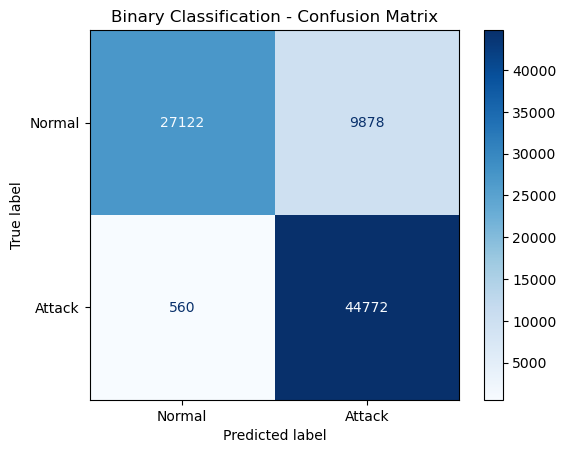

False Positive Rate (FPR): 0.2670
False Negative Rate (FNR): 0.0124


In [3]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Preprocessing

# Identify categorical columns
cat_cols = ['proto', 'service', 'state', 'attack_cat']

# Encode categorical features with LabelEncoder since XGBoost only accept numerical values
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[col], test_df[col]]).astype(str))
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    label_encoders[col] = le

# Prepare features and target for binary classification
drop_cols = ['id', 'label', 'attack_cat']
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label']
X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label']

# Train XGBoost (Binary)
bst = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='logloss'
)
bst.fit(X_train, y_train)

# Predictions & Evaluation
preds = bst.predict(X_test)

report = classification_report(y_test, preds, target_names=['Normal', 'Attack'], output_dict=True)
report_df = pd.DataFrame(report).transpose()
display(report_df)

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap='Blues')
plt.title("Binary Classification - Confusion Matrix")
plt.show()

# FPR and FNR
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")

**Preprocessing Justification:**
- **Label Encoding** over one-hot encoding for `proto`, `service`, `state`: avoids sparse high-dimensional matrices; XGBoost's tree splits handle integer-encoded categories natively.
- **Encoder fitted on train + test union** to handle unseen values (e.g., `ACC` only appears in test set).
- **Dropped `id`** (no predictive value) and **`attack_cat`** (would cause data leakage in binary classification).
- **Predefined train/test split** preserved for reproducibility with the UNSW-NB15 benchmark.


### 1.2 Class Attack Category Classification

,precision,recall,f1-score,support
Analysis,0.058904,0.063516,0.061123,677.000000
Backdoor,0.042625,0.108062,0.061135,583.000000
DoS,0.486842,0.081438,0.139535,4089.000000
Exploits,0.594646,0.866062,0.705138,11132.000000
Fuzzers,0.308802,0.603596,0.408576,6062.000000
Generic,0.996027,0.969742,0.982709,18871.000000
Normal,0.963847,0.756568,0.847720,37000.000000
Reconnaissance,0.927237,0.809211,0.864213,3496.000000
Shellcode,0.322691,0.748677,0.450996,378.000000
Worms,0.705882,0.545455,0.615385,44.000000


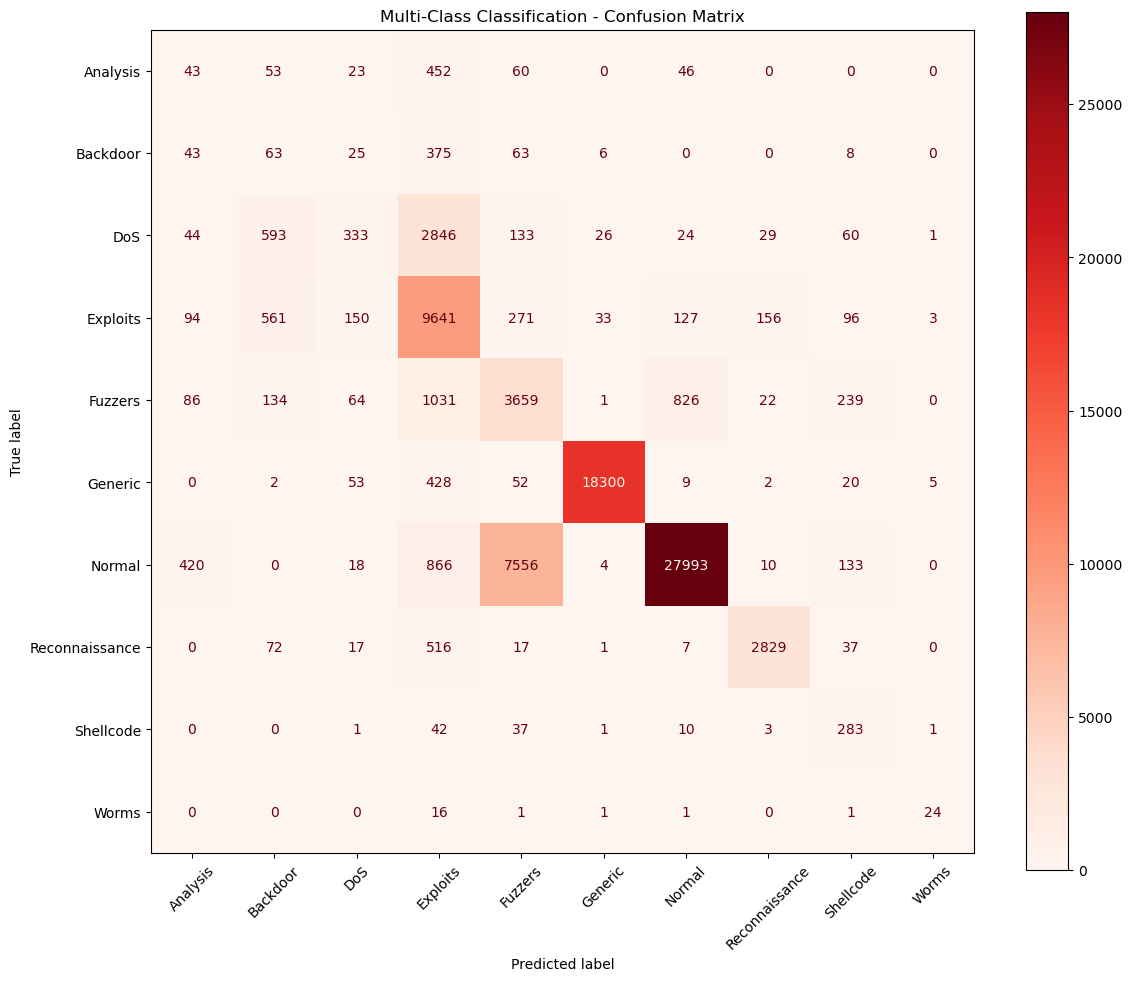

In [4]:
# --- 1.2 Multi-Class Attack Category Classification ---

X_train_mc = train_df.drop(columns=drop_cols)
y_train_mc = train_df['attack_cat']
X_test_mc = test_df.drop(columns=drop_cols)
y_test_mc = test_df['attack_cat']

attack_names = label_encoders['attack_cat'].classes_

bst_mc = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=len(attack_names),
    eval_metric='mlogloss'
)
bst_mc.fit(X_train_mc, y_train_mc)

preds_mc = bst_mc.predict(X_test_mc)

# Per-class Recall and F1-score
report_mc = classification_report(y_test_mc, preds_mc, target_names=attack_names, output_dict=True)
report_mc_df = pd.DataFrame(report_mc).transpose()
display(report_mc_df)

# Multi-class Confusion Matrix
cm_mc = confusion_matrix(y_test_mc, preds_mc)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm_mc, display_labels=attack_names).plot(cmap='Reds', ax=ax, xticks_rotation=45)
plt.title("Multi-Class Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

# 2. Context-Aware Feature Semantics

### 2.1 Group the dataset features by meaningful cybersecurity categories



In [5]:
print(train_df.columns.tolist())

['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']



### 2.2 Attack Behavior Profiling

In [6]:
# Reload original data for profiling analysis
train_raw = pd.read_csv("Datasets/UNSW_NB15_training-set.csv")
test_raw = pd.read_csv("Datasets/UNSW_NB15_testing-set.csv")
df_raw = pd.concat([train_raw, test_raw], ignore_index=True)

# Filter selected attack categories + Normal
selected = ['DoS', 'Exploits', 'Reconnaissance', 'Normal']
df_profile = df_raw[df_raw['attack_cat'].str.strip().isin(selected)].copy()
df_profile['attack_cat'] = df_profile['attack_cat'].str.strip()

print(df_profile['attack_cat'].value_counts())

attack_cat
Normal            93000
Exploits          44525
DoS               16353
Reconnaissance    13987
Name: count, dtype: int64


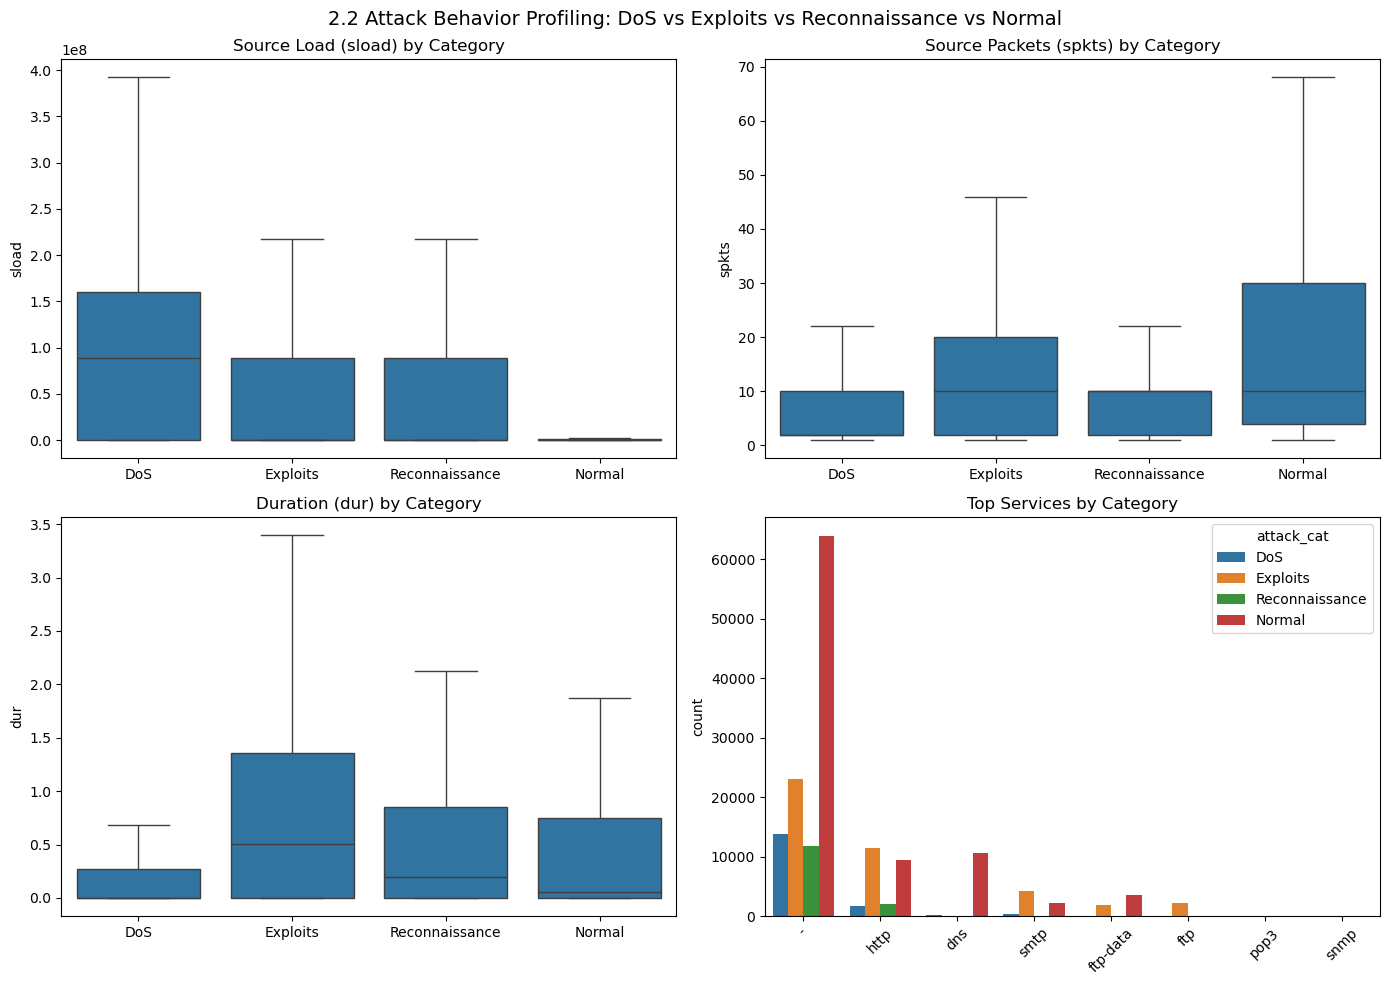

In [12]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Load features (Sload)
sns.boxplot(data=df_profile, x='attack_cat', y='sload', order=selected, ax=axes[0, 0], showfliers=False)
axes[0, 0].set_title("Source Load (sload) by Category")
axes[0, 0].set_xlabel("")

# 2. Packet features (spkts)
sns.boxplot(data=df_profile, x='attack_cat', y='spkts', order=selected, ax=axes[0, 1], showfliers=False)
axes[0, 1].set_title("Source Packets (spkts) by Category")
axes[0, 1].set_xlabel("")

# 3. Duration
sns.boxplot(data=df_profile, x='attack_cat', y='dur', order=selected, ax=axes[1, 0], showfliers=False)
axes[1, 0].set_title("Duration (dur) by Category")
axes[1, 0].set_xlabel("")

# 4. Service usage
top_services = (df_profile.groupby(['attack_cat', 'service'])
                .size()
                .reset_index(name='count')
                .sort_values('count', ascending=False)
                .groupby('attack_cat')
                .head(5))

sns.barplot(data=top_services, x='service', y='count', hue='attack_cat', hue_order=selected, ax=axes[1, 1])
axes[1, 1].set_title("Top Services by Category")
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_xlabel("")

plt.suptitle("2.2 Attack Behavior Profiling: DoS vs Exploits vs Reconnaissance vs Normal", fontsize=14)
plt.tight_layout()
plt.show()

# 3. Misclassification and Security Error Analysis

### 3.1 Misclassification and Security Error Analysis


In [ ]:
# Reload raw test data for readable feature values
test_raw = pd.read_csv("Datasets/UNSW_NB15_testing-set.csv")

# Get false negatives: actual attack (label=1) predicted as normal (0)
fn_mask = (y_test == 1) & (preds == 0)
fn_indices = y_test[fn_mask].index

fn_samples = test_raw.loc[fn_indices]
print(f"Total false negatives: {fn_samples.shape[0]}")
print("\nAttack categories missed:")
print(fn_samples['attack_cat'].str.strip().value_counts())

Total false negatives: 560

Attack categories missed:
attack_cat
Fuzzers           500
Exploits           38
Analysis           13
Reconnaissance      4
Shellcode           2
DoS                 2
Generic             1
Name: count, dtype: int64


In [14]:
# Show examples of false negative samples with key features
fn_display = fn_samples[['attack_cat', 'proto', 'service', 'state', 'dur', 'spkts', 'dpkts', 'sload', 'dload', 'sbytes', 'dbytes']].copy()
fn_display['attack_cat'] = fn_display['attack_cat'].str.strip()

# Show 5 examples per top missed category
for cat in ['Fuzzers', 'Exploits', 'Analysis']:
    print(f"\n--- False Negatives: {cat} ---")
    display(fn_display[fn_display['attack_cat'] == cat].head(5))


--- False Negatives: Fuzzers ---


,attack_cat,proto,service,state,dur,spkts,dpkts,sload,dload,sbytes,dbytes
277,Fuzzers,tcp,-,FIN,0.523646,10,6,9273.440430,3422.159180,674,268
282,Fuzzers,tcp,-,FIN,0.566928,10,6,6223.012207,3160.895020,490,268
283,Fuzzers,tcp,-,FIN,0.833854,10,8,6380.013672,2974.141602,738,354
309,Fuzzers,tcp,-,FIN,0.596682,12,6,45210.011720,3003.274658,3678,268
313,Fuzzers,tcp,-,FIN,1.189909,10,8,4349.912598,2084.193115,718,354



--- False Negatives: Exploits ---


,attack_cat,proto,service,state,dur,spkts,dpkts,sload,dload,sbytes,dbytes
295,Exploits,tcp,http,FIN,0.772218,10,10,7541.911621,11551.142580,808,1238
458,Exploits,tcp,-,ACC,0.012899,2,2,29769.750000,29769.750000,96,96
2069,Exploits,tcp,-,FIN,0.927634,10,8,7718.561523,2673.468262,994,354
5718,Exploits,tcp,-,FIN,0.782885,10,10,5599.800781,5947.233398,608,646
7882,Exploits,tcp,-,FIN,0.968888,10,10,4524.774902,4805.509277,608,646



--- False Negatives: Analysis ---


,attack_cat,proto,service,state,dur,spkts,dpkts,sload,dload,sbytes,dbytes
58436,Analysis,tcp,-,FIN,0.669570,10,8,9032.662109,12796.27148,840,1224
58440,Analysis,tcp,-,FIN,0.567755,10,8,10229.764650,14301.94434,806,1160
59636,Analysis,tcp,-,FIN,0.526913,10,8,11295.982420,17460.18750,826,1314
60319,Analysis,tcp,-,FIN,0.606981,10,10,9950.888672,15974.14160,838,1346
61548,Analysis,tcp,-,FIN,0.721151,10,8,8408.780273,11825.54004,842,1218


### 3.2 False Positive Security Interpretation

In [15]:
fp_mask = (y_test == 0) & (preds == 1)
fp_indices = y_test[fp_mask].index

fp_samples = test_raw.loc[fp_indices]
print(f"Total false positives: {fp_samples.shape[0]}")

# Show examples with key features
fp_display = fp_samples[['attack_cat', 'proto', 'service', 'state', 'dur', 'spkts', 'dpkts', 'sload', 'dload', 'sbytes', 'dbytes']].head(10)
display(fp_display)

Total false positives: 9878


,attack_cat,proto,service,state,dur,spkts,dpkts,sload,dload,sbytes,dbytes
0,Normal,udp,-,INT,0.000011,2,0,1.803636e+08,0.0,496,0
1,Normal,udp,-,INT,0.000008,2,0,8.810000e+08,0.0,1762,0
2,Normal,udp,-,INT,0.000005,2,0,8.544000e+08,0.0,1068,0
3,Normal,udp,-,INT,0.000006,2,0,6.000000e+08,0.0,900,0
4,Normal,udp,-,INT,0.000010,2,0,8.504000e+08,0.0,2126,0
5,Normal,udp,-,INT,0.000003,2,0,1.045333e+09,0.0,784,0
6,Normal,udp,-,INT,0.000006,2,0,1.306667e+09,0.0,1960,0
7,Normal,udp,-,INT,0.000028,2,0,1.977143e+08,0.0,1384,0
12,Normal,udp,-,INT,0.000004,2,0,1.454000e+09,0.0,1454,0
13,Normal,udp,-,INT,0.000007,2,0,1.178286e+09,0.0,2062,0


# 4. Trustworthy Security Interpretation (SOC Perspective)

### 4.1 Security-Centric Evaluation



**Why high accuracy alone is insufficient:**
Our binary model achieves 87.4% accuracy, but this masks 560 missed attacks and 9,878 false alarms. Accuracy treats both error types as equally costly, which is fundamentally flawed in cybersecurity. A model that labels everything as "Normal" could still achieve high accuracy on imbalanced datasets while missing every attack.

**Impact of False Negatives (missed attacks):**
A single undetected intrusion can lead to data breaches, ransomware, or lateral movement across the network. Our analysis showed 500 Fuzzers and 38 Exploits evading detection by mimicking normal traffic. The cost of one missed exploit far exceeds thousands of false alarms, making recall more security-relevant than accuracy.

**Impact of False Positives (alert fatigue):**
Our model's FPR of 26.7% means over a quarter of benign traffic triggers alerts. In a 24/7 SOC, this leads to alert fatigue: analysts begin dismissing alerts without investigation. This effectively neutralizes the IDS and paradoxically increases the risk of missing real attacks.

**Trust in automated ML-based IDS:**
Flow-level features cannot capture payload-based attacks like Fuzzers that generate structurally normal traffic. ML-based IDS should serve as a triage layer prioritizing alerts for human review, not as a standalone decision-maker. Confidence scores, explainable feature contributions (SHAP), and threat intelligence correlation are necessary to build analyst trust in SOC environments.